# Chapter 54 — Attention as Weighted Averaging

## Learning goals

Chapter 53 motivated an operation that keeps token positions separate and mixes them according to the current input.

This chapter isolates the mixing operation before explaining how a model computes its weights.

By the end of this chapter, you should be able to:

- Explain attention output as a weighted average over allowed sequence positions.
- Define attention weights and their position domain.
- Explain why normalized weights are nonnegative and sum to one.
- Compute and print every weighted vector contribution.
- Plot a manual attention distribution.
- Distinguish attention weights from next-token vocabulary probabilities.
- Arrange one distribution per receiving position in an attention matrix.
- Compute all position outputs with matrix multiplication.
- Explain what remains unknown before queries, keys, and values are introduced.

## The big idea

Consider four token positions:

```text
the small dog barked
```

To build a context vector after `barked`, assign one weight to each allowed position and add the weighted token vectors.

For manual weights `[0.1, 0.2, 0.6, 0.1]`:

```text
context vector =
    0.1 × vector("the")
  + 0.2 × vector("small")
  + 0.6 × vector("dog")
  + 0.1 × vector("barked")
```

The result is a vector rather than a selected word.

## Terms used in this chapter

- A **token position** is one location in a sequence.
- A **token vector** represents the token information at one position.
- An **attention weight** is a nonnegative mixing coefficient assigned to an allowed position.
- An **attention distribution** is a normalized list of weights over allowed positions.
- A **weighted contribution** is one vector multiplied by its attention weight.
- A **weighted average** is the sum of weighted vectors whose weights sum to one.
- A **context vector** is the mixed vector produced for one receiving position.
- A **causal restriction** prevents a receiving position from using future positions.
- A **vocabulary distribution** assigns probabilities to possible output tokens rather than input positions.

## Create one vector per token position

Use simple three-number vectors so every weighted contribution remains visible.

Real models learn richer vectors, and later attention layers may transform them before mixing.

In [1]:
import torch

device = "cpu"
tokens = ["the", "small", "dog", "barked"]
token_vectors = torch.tensor(
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0],
        [1.0, 1.0, 0.0],
    ],
    dtype=torch.float32,
    device=device,
)

print("device:", device)
print("token vector shape:", token_vectors.shape)
print()
print("position | token  | vector")
print("-" * 42)
for position, token in enumerate(tokens):
    print(f"{position:>8} | {token:>6} | {token_vectors[position].tolist()}")

device: cpu
token vector shape: torch.Size([4, 3])

position | token  | vector
------------------------------------------
       0 |    the | [1.0, 0.0, 0.0]
       1 |  small | [0.0, 1.0, 0.0]
       2 |    dog | [0.0, 0.0, 1.0]
       3 | barked | [1.0, 1.0, 0.0]


The shape `[4, 3]` means four sequence positions with a three-dimensional vector at each position.

This chapter omits the batch dimension for clarity, so `[C, D]` stands in for the later `[B, C, D]` shape.

## Define and validate manual weights

The four weights correspond by index to the four input positions.

Validation makes the mathematical weighted-average contract explicit.

In [2]:
def validate_attention_weights(
    weights: torch.Tensor,
    tolerance: float = 1e-6,
) -> None:
    if weights.ndim != 1:
        raise ValueError("weights must be one-dimensional.")
    if not torch.is_floating_point(weights):
        raise ValueError("weights must use a floating-point dtype.")
    if not torch.all(torch.isfinite(weights)):
        raise ValueError("weights must contain only finite values.")
    if torch.any(weights < 0):
        raise ValueError("weights must be nonnegative.")

    expected_sum = torch.tensor(1.0, dtype=weights.dtype, device=weights.device)
    if not torch.isclose(
        weights.sum(),
        expected_sum,
        rtol=0.0,
        atol=tolerance,
    ):
        raise ValueError("weights must sum to 1.")


attention_weights = torch.tensor(
    [0.1, 0.2, 0.6, 0.1],
    dtype=torch.float32,
    device=device,
)
validate_attention_weights(attention_weights)

print("position | token  | weight")
print("-" * 30)
for position, token in enumerate(tokens):
    print(f"{position:>8} | {token:>6} | {attention_weights[position].item():.3f}")
print("sum:", attention_weights.sum().item())

position | token  | weight
------------------------------
       0 |    the | 0.100
       1 |  small | 0.200
       2 |    dog | 0.600
       3 | barked | 0.100
sum: 1.0


Nonnegative weights that sum to one define a probability distribution mathematically over the four positions.

Normalization keeps the output a weighted average and makes positions compete for a fixed total weight.

An attention weight is not automatically a calibrated probability that a token is important, nor is it by itself an explanation of a prediction.

## Plot the attention distribution

A bar chart makes the domain and relative weights visible.

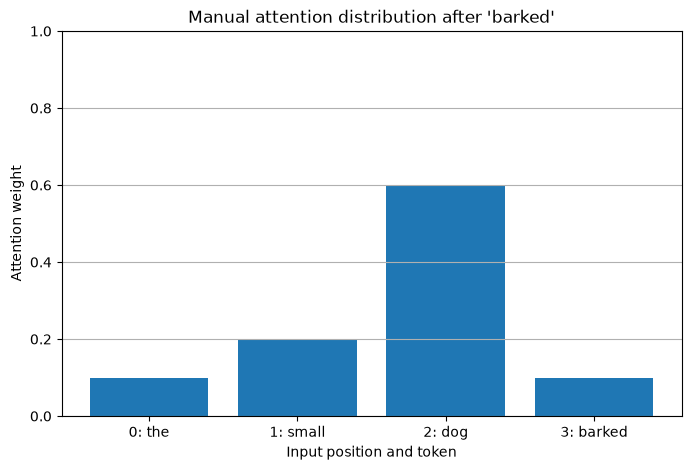

In [3]:
import matplotlib.pyplot as plt

position_labels = [f"{position}: {token}" for position, token in enumerate(tokens)]

plt.figure(figsize=(8, 5))
plt.bar(position_labels, attention_weights.tolist())
plt.xlabel("Input position and token")
plt.ylabel("Attention weight")
plt.title("Manual attention distribution after 'barked'")
plt.ylim(0.0, 1.0)
plt.grid(axis="y")
plt.show()

Position 2, containing `dog`, contributes the largest coefficient in this hand-written example.

The chart displays a distribution over four input positions rather than over possible next tokens.

## Compute every weighted contribution

Multiplying the `[4]` weights as a `[4, 1]` column by the `[4, 3]` vectors scales each row independently.

In [4]:
weighted_contributions = attention_weights.unsqueeze(1) * token_vectors
attention_output = weighted_contributions.sum(dim=0)

print("token  | weight | original vector       | weighted contribution")
print("-" * 78)
for position, token in enumerate(tokens):
    original_vector = [round(value, 3) for value in token_vectors[position].tolist()]
    contribution = [
        round(value, 3) for value in weighted_contributions[position].tolist()
    ]
    print(
        f"{token:>6} | "
        f"{attention_weights[position].item():>6.3f} | "
        f"{str(original_vector):>21} | "
        f"{contribution}"
    )

print()
print("attention output:", attention_output)
print("attention output shape:", attention_output.shape)

token  | weight | original vector       | weighted contribution
------------------------------------------------------------------------------
   the |  0.100 |       [1.0, 0.0, 0.0] | [0.1, 0.0, 0.0]
 small |  0.200 |       [0.0, 1.0, 0.0] | [0.0, 0.2, 0.0]
   dog |  0.600 |       [0.0, 0.0, 1.0] | [0.0, 0.0, 0.6]
barked |  0.100 |       [1.0, 1.0, 0.0] | [0.1, 0.1, 0.0]

attention output: tensor([0.2000, 0.3000, 0.6000])
attention output shape: torch.Size([3])


The `dog` contribution is `[0.0, 0.0, 0.6]`, which supplies the entire third component of the result.

Adding the four contributions produces `[0.2, 0.3, 0.6]`.

The position dimension is reduced, leaving one context vector with dimension `D=3`.

## Write a reusable weighted-average helper

The helper checks vector shape, row alignment, device alignment, and the normalized-weight contract before multiplying.

In [5]:
def compute_weighted_average(
    vectors: torch.Tensor,
    weights: torch.Tensor,
) -> torch.Tensor:
    if vectors.ndim != 2:
        raise ValueError(
            "vectors must have shape [number of positions, vector dimension]."
        )
    if vectors.shape[0] != weights.shape[0]:
        raise ValueError("vectors and weights must have the same number of positions.")
    if vectors.device != weights.device:
        raise ValueError("vectors and weights must use the same device.")

    validate_attention_weights(weights)
    return weights @ vectors


helper_output = compute_weighted_average(
    vectors=token_vectors,
    weights=attention_weights,
)
expected_output = torch.tensor(
    [0.2, 0.3, 0.6],
    dtype=torch.float32,
    device=device,
)

print("helper output:", helper_output)
print("expected output:", expected_output)
print("matches manual arithmetic:", torch.allclose(helper_output, expected_output))
print(
    "matches summed contributions:",
    torch.allclose(helper_output, attention_output),
)

helper output: tensor([0.2000, 0.3000, 0.6000])
expected output: tensor([0.2000, 0.3000, 0.6000])
matches manual arithmetic: True
matches summed contributions: True


The vector-matrix product `[4] @ [4, 3]` performs the same weighted sum as the explicit contribution table.

## Changing weights changes the mixture

Use a second valid distribution that emphasizes the final `barked` position.

In [6]:
different_attention_weights = torch.tensor(
    [0.05, 0.05, 0.20, 0.70],
    dtype=torch.float32,
    device=device,
)
different_attention_output = compute_weighted_average(
    vectors=token_vectors,
    weights=different_attention_weights,
)

print("dog-focused weights:", attention_weights)
print("dog-focused output:", attention_output)
print()
print("barked-focused weights:", different_attention_weights)
print("barked-focused output:", different_attention_output)

dog-focused weights: tensor([0.1000, 0.2000, 0.6000, 0.1000])
dog-focused output: tensor([0.2000, 0.3000, 0.6000])

barked-focused weights: tensor([0.0500, 0.0500, 0.2000, 0.7000])
barked-focused output: tensor([0.7500, 0.7500, 0.2000])


The second output is `[0.75, 0.75, 0.20]` because the final vector contributes strongly to its first two components.

A real layer needs a rule that changes weights from one receiving position and input sequence to another.

## Attention and vocabulary distributions have different domains

Attention answers where a context vector gathers information from.

A vocabulary distribution answers which token the model may output next.

Print both domains side by side using an explicitly fake vocabulary distribution.

In [7]:
possible_next_tokens = ["loudly", ".", "again", "at"]
fake_vocabulary_probabilities = torch.tensor(
    [0.3, 0.4, 0.2, 0.1],
    dtype=torch.float32,
    device=device,
)

print("Attention distribution over input positions")
print("-" * 45)
for position, token in enumerate(tokens):
    print(f"position {position} ({token!r}): {attention_weights[position].item():.3f}")

print()
print("Fake vocabulary distribution over output tokens")
print("-" * 48)
for token, probability in zip(
    possible_next_tokens,
    fake_vocabulary_probabilities,
    strict=True,
):
    print(f"token {token!r}: {probability.item():.3f}")

Attention distribution over input positions
---------------------------------------------
position 0 ('the'): 0.100
position 1 ('small'): 0.200
position 2 ('dog'): 0.600
position 3 ('barked'): 0.100

Fake vocabulary distribution over output tokens
------------------------------------------------
token 'loudly': 0.300
token '.': 0.400
token 'again': 0.200
token 'at': 0.100


Both lists happen to contain four normalized numbers, but matching lengths do not give them the same meaning.

The attention domain is the current sequence's positions, while the vocabulary domain is the model's fixed set of possible output tokens.

Attention produces a vector that later layers can convert into vocabulary logits.

## Give every position its own distribution

For left-to-right prediction, a position may use itself and earlier positions but not future positions.

Arrange one manual distribution per receiving position in a `[C, C]` matrix.

Rows identify receiving positions, and columns identify contributing positions.

In [8]:
attention_matrix = torch.tensor(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.5, 0.5, 0.0, 0.0],
        [0.2, 0.2, 0.6, 0.0],
        [0.1, 0.2, 0.6, 0.1],
    ],
    dtype=torch.float32,
    device=device,
)

for row in attention_matrix:
    validate_attention_weights(row)

print("attention matrix:")
print(attention_matrix)
print("shape:", attention_matrix.shape)
print("row sums:", attention_matrix.sum(dim=1))
print(
    "future-position entries are zero:",
    bool(torch.all(torch.triu(attention_matrix, diagonal=1) == 0)),
)

attention matrix:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.6000, 0.0000],
        [0.1000, 0.2000, 0.6000, 0.1000]])
shape: torch.Size([4, 4])
row sums: tensor([1., 1., 1., 1.])
future-position entries are zero: True


Zeros above the diagonal enforce the causal restriction in this manual matrix.

The final row matches the original distribution because the final position may gather from all four positions.

## Compute all context vectors at once

Matrix multiplication applies every row distribution to the same position vectors.

In [9]:
all_attention_outputs = attention_matrix @ token_vectors

print("matrix shape:", attention_matrix.shape)
print("token vector shape:", token_vectors.shape)
print("output shape:", all_attention_outputs.shape)
print()
print("receiving position | token  | context vector")
print("-" * 60)
for position, token in enumerate(tokens):
    rounded_output = [
        round(value, 3) for value in all_attention_outputs[position].tolist()
    ]
    print(f"{position:>18} | {token:>6} | {rounded_output}")

print()
print(
    "final row matches one-position output:",
    torch.allclose(all_attention_outputs[-1], attention_output),
)

matrix shape: torch.Size([4, 4])
token vector shape: torch.Size([4, 3])
output shape: torch.Size([4, 3])

receiving position | token  | context vector
------------------------------------------------------------
                 0 |    the | [1.0, 0.0, 0.0]
                 1 |  small | [0.5, 0.5, 0.0]
                 2 |    dog | [0.2, 0.2, 0.6]
                 3 | barked | [0.2, 0.3, 0.6]

final row matches one-position output: True


The output retains shape `[C, D]`, so every receiving position remains a separate row with a new context vector.

Unlike immediate flattening, this operation mixes information without removing the sequence axis.

A batched implementation will extend these shapes to `[B, C, C] @ [B, C, D] → [B, C, D]`.

## Where the manual explanation stops

This chapter supplied attention weights by hand.

It has not explained how a model should produce different valid distributions from different token vectors.

Queries and keys will provide scores that determine the weights, and values will provide the vectors being mixed.

Those roles are easier to separate after the weighted-average operation and its shapes are concrete.

## Common mistakes

- Do not confuse a distribution over positions with a distribution over vocabulary tokens.
- Do not call arbitrary unnormalized coefficients a weighted average.
- Do not allow negative, infinite, or `NaN` attention weights in this normalized setup.
- Do not assume attention must choose exactly one position because it usually mixes several.
- Do not treat a large attention weight as a complete explanation of a prediction.
- Do not allow future-position weights in causal left-to-right attention.
- Do not forget that the manual token vectors will later be replaced by learned representations and transformations.

## Takeaways

Attention mixing computes a weighted average of vectors from allowed sequence positions.

For one receiving position, `[C] @ [C, D]` produces one `[D]` context vector.

For every position, `[C, C] @ [C, D]` produces `[C, D]` context vectors while preserving the sequence axis.

Normalized attention weights form a mathematical distribution over positions, not a next-token vocabulary distribution.

The weights in this chapter are manual, so the next task is to compute them from the current representations.

## What comes next

The next chapter introduces the roles that queries, keys, and values play in attention.

Queries and keys will help produce content-dependent weights, while values will carry the information combined by the weighted average developed here.